In [65]:
from autoslo.blueprint_selection.query_timeline import QueryTimeline
from autoslo.blueprints.cluster import Cluster
from autoslo.workload_execution.trace import Trace
from autoslo.models.iconq_model import IconqModel

run_id = '1763278486'
iconq_model_id = '1767983798'

trace  = Trace(run_id=run_id)
model = IconqModel.load(model_id=iconq_model_id)

timeline = QueryTimeline(model._iconq_query_featurizer, model._iconq_interaction_featurizer)
timeline.initialize_from_trace(trace, model.stage_model)

Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1767983798/model_1767985867.pth


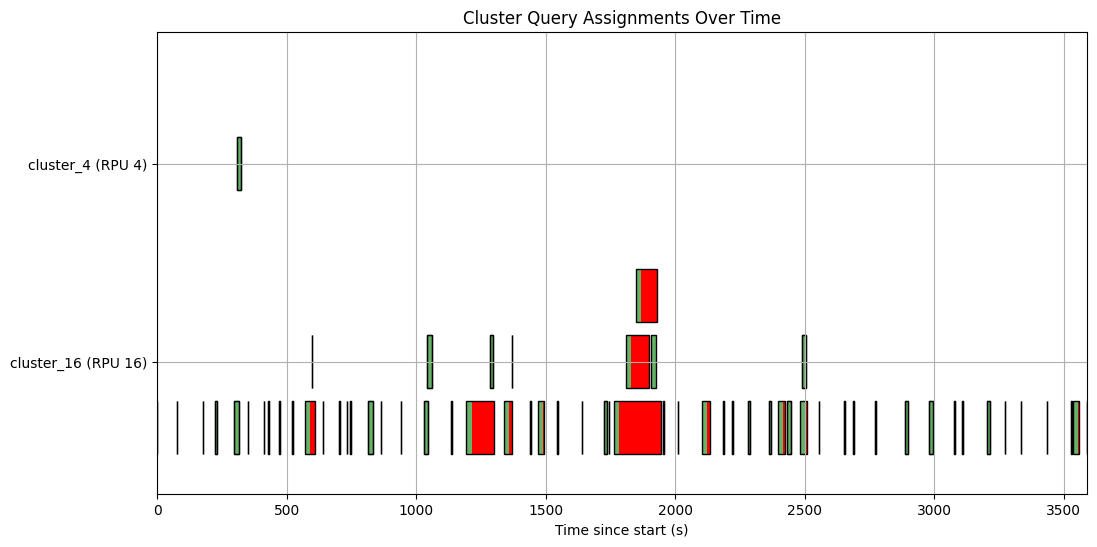

In [53]:
timeline.draw_gantt_chart(slo_s=20.0)

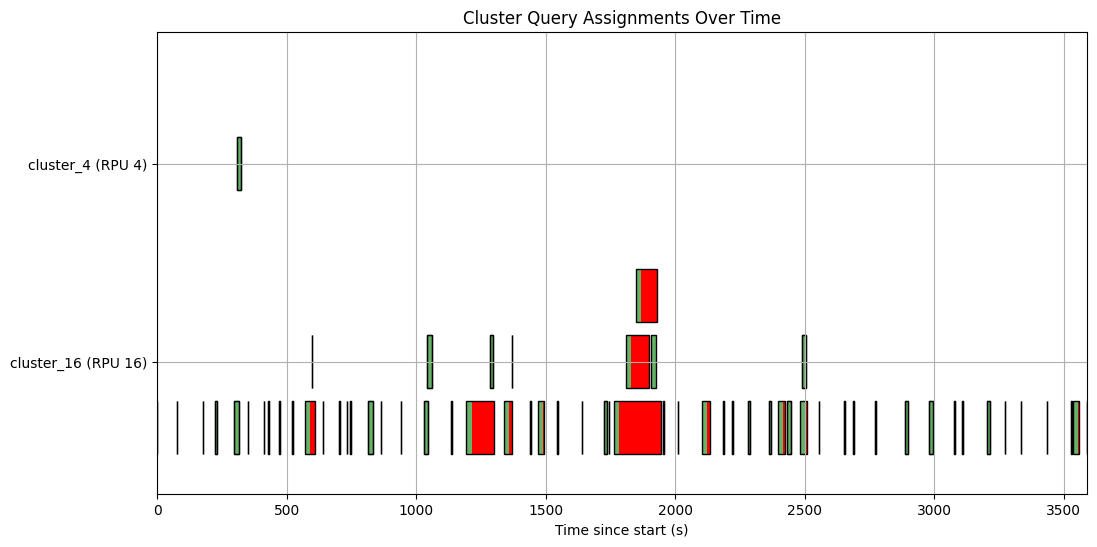

In [7]:
# Move a query and replot
query_id_to_move = trace.query_ids[5]
timeline.move_to_cluster(query_id = query_id_to_move, new_cluster_name='cluster_4')

timeline.draw_gantt_chart(slo_s=20.0)


In [64]:
from autoslo.blueprint_selection.query_timeline_visualizer import GanttRecorder, render_gantt_scrubber

rec = GanttRecorder()

rec.snapshot(timeline, label="start")
query_id_to_move = trace.query_ids[5]
timeline.move_to_cluster(query_id = query_id_to_move, new_cluster_name='cluster_4')
rec.snapshot(timeline, label=f"moved {query_id_to_move} to cluster_4")


fig = render_gantt_scrubber(
    rec.snapshots,
    slo_s=20.0,
)

fig.show()

In [14]:
timeline._query_id_to_cluster_interval[query_id_to_move]

('cluster_4',
 Interval(1763278486.650039, 1763278487.191643, {'query_id': 'cluster_16_11783886#4eca061a-cb54-48b3-86cf-ca2145c3db08', 'tpcds_temp_and_q_idx': '019_003', 'featurization': [0.0, 0.0, 5.0, 17.701459900591274, 2.0, 17.61858988029538, 1.0, 9.67595940353184, 1.0, 9.67595940353184, 1.0, 21.23075439128468, 0.0, 0.0, 1.0, 9.67595940353184, 0.0, 0.0, 1.0, 9.67595940353184, 0.0, 0.0, 1.0, 8.682707631588727, 0.0, 0.0, 2.0, 17.704842456452802, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'stage_model_predictions_per_rpu': {32: 6.9744053333333325, 64: np.float32(3.0786684), 128: np.float32(3.0786684), 256: np.float32(3.0786684), 4: 174.72313999999997, 512: np.float32(3.0786684), 8: 16.121851888888887, 16: 7.47579411111111}}))

In [8]:
trace.run_id

'1763278486'

In [92]:
from autoslo.blueprint_selection.selector import BlueprintSelector
from autoslo.workload_definition.chunk import Chunk

workload = Chunk.load('tpcds_99templates_25pctheavy_60meaninterarrivals')

selector = BlueprintSelector(
    workload=workload,
    slo_s=20.0,
    slo_violation_rate_threshold=0.05,
    iconq_model_id = iconq_model_id,
    default_cluster_name = 'cluster_8'
)
selector.solve()

Loading model checkpoint from /home/markakis/chunkbench/data/iconq_models/1767983798/model_1767985867.pth


Bootstrapping latencies:   0%|          | 0/100 [00:00<?, ?it/s]

SLO iteration 0: reduced SLO violation rate from 0.7143 to 0.6190 by applying move QueryMove(query_id=61, from_cluster_name='cluster_8', to_cluster_name='cluster_16').
SLO iteration 1: reduced SLO violation rate from 0.6508 to 0.5714 by applying move QueryMove(query_id=44, from_cluster_name='cluster_8', to_cluster_name='cluster_16').
SLO iteration 2: reduced SLO violation rate from 0.5714 to 0.5556 by applying move QueryMove(query_id=53, from_cluster_name='cluster_8', to_cluster_name='cluster_32').
SLO iteration 3: reduced SLO violation rate from 0.6190 to 0.4921 by applying move QueryMove(query_id=33, from_cluster_name='cluster_8', to_cluster_name='cluster_64').
SLO iteration 4: reduced SLO violation rate from 0.5714 to 0.4762 by applying move QueryMove(query_id=34, from_cluster_name='cluster_8', to_cluster_name='cluster_32').
SLO iteration 5: reduced SLO violation rate from 0.4762 to 0.3810 by applying move QueryMove(query_id=47, from_cluster_name='cluster_8', to_cluster_name='cluste

In [91]:
fig = render_gantt_scrubber(
    selector._recorder.snapshots,
    slo_s=selector._slo_s,
    constant_layout=True,
    violation_rate_threshold=0.05
)
fig.write_html("blueprint_selection_timeline.html", auto_play=False)

AttributeError: 'NoneType' object has no attribute 'get'

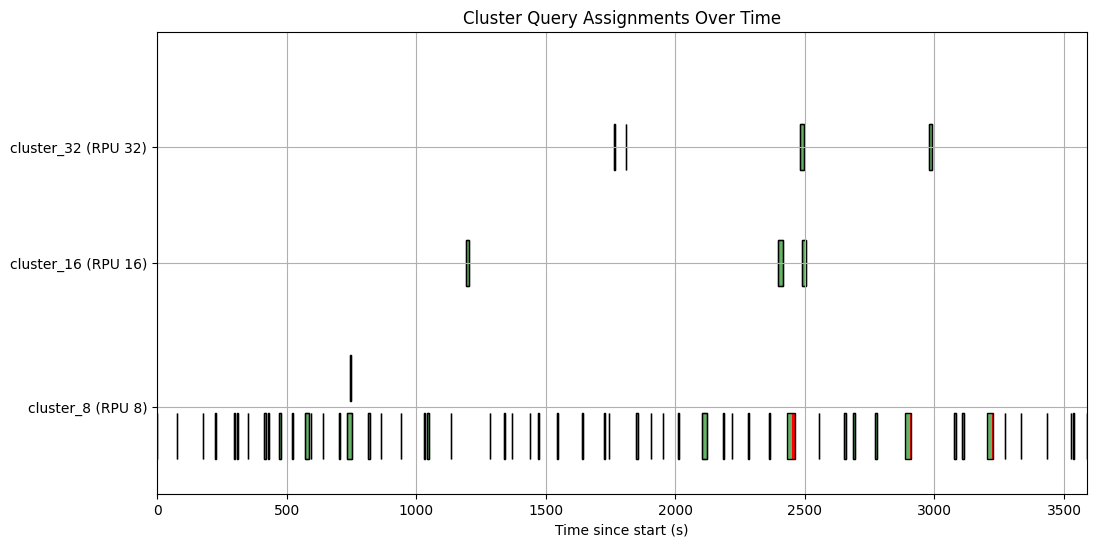

In [50]:
selector._query_timeline.draw_gantt_chart(
    slo_s=20.0)


In [51]:
selector._query_timeline.slo_violation_rate(slo_s=20.0)

0.047619047619047616

In [45]:
import pandas as pd
# Make sure that each interval is identically represented in the two data structures
rows = []
count_1 = 0
count_2 = 0
for query_id in selector._query_timeline.query_ids:
    count_1 += 1    
    cluster_name, interval = selector._query_timeline._query_id_to_cluster_interval[query_id]
    start_time = interval.begin
    end_time = interval.end
    row = {
        'query_id': query_id,
        'cluster_name_dict': cluster_name,
        'interval_tree_start_dict': start_time,
        'interval_tree_end_dict': end_time
    }
    rows.append(row)

rows_df = pd.DataFrame(rows)
rows_df['cluster_name_tree'] = None
rows_df['interval_tree_start_tree'] = None
rows_df['interval_tree_end_tree'] = None

for cluster_name, interval_tree in selector._query_timeline._interval_trees.items():
    for interval in interval_tree:
        count_2 += 1
        query_id = interval.data['query_id']
        rows_df.loc[rows_df['query_id'] == query_id, 'cluster_name_tree'] = cluster_name
        rows_df.loc[rows_df['query_id'] == query_id, 'interval_tree_start_tree'] = interval.begin
        rows_df.loc[rows_df['query_id'] == query_id, 'interval_tree_end_tree'] = interval.end



In [47]:
assert all(rows_df['cluster_name_dict'] == rows_df['cluster_name_tree'])
assert all(rows_df['interval_tree_start_dict'] == rows_df['interval_tree_start_tree'])
assert all(rows_df['interval_tree_end_dict'] == rows_df['interval_tree_end_tree'])